# Introduction to the Weights Quantization

## Theory

https://arxiv.org/pdf/2106.08295

### What is Quantization?

Weight quantization is a technique used to reduce the precision of the model weights. This process involves converting the weights from high-precision formats (e.g., 32-bit floating-point numbers) to lower-precision formats (e.g., 8-bit integers or even binary values).

### Why Use Quantization?

- **Reduced Memory Usage.** Lower-precision weights require less memory storage. For example, switching from `float32` to `int8` reduces memory usage by a factor of 4.

- **Faster Inference.** Operations on lower-precision numbers are computationally cheaper. For instance, integer arithmetic is faster than floating-point arithmetic on most hardware.

- **Improved Deployment.** Quantized models are easier to deploy on edge devices with limited computational resources.

### Quantization Types

- **Post-Training Quantization (PTQ).** Applied after the model has been trained. This is simpler but may result in some loss of accuracy.
- **Quantization-aware Training (QAT).** Incorporates quantization effects during training, allowing the model to adapt to the reduced precision. This generally results in better accuracy compared to post-training quantization.


### Linear Quantizations

#### Simmetric Signed Quantization

Maps $0 \rightarrow 0$ and $|\max(w_i)| \rightarrow 2^{b-1} - 1$.

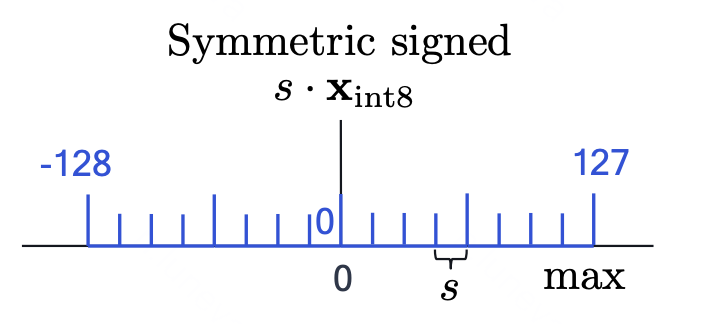

$$x_{int} = \text{clamp}\left(\lfloor \frac{x}{s} \rceil; -2^{b-1}, 2^{b-1}-1 \right)$$

$$\hat{x} = s \cdot x_{int}$$

where:
- $x$ — original real value
- $x_{int}$ - quantized value
- $\hat{x}$ — dequantized value
- $s$ — scale factor
- $b$ — bit-width (number of bits)
- $\lfloor \cdot \rceil$ — rounding operator to the nearest integer
- $\text{clamp}(x; a, c)$ — clamping function

#### Simmetric Unsigned Quantization

Maps $0 \rightarrow 0$ and $|\max(w_i)| \rightarrow 2^{b} - 1$.

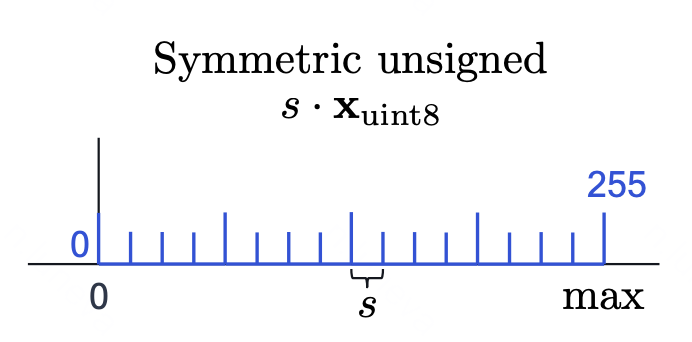

$$x_{int} = \text{clamp}\left(\lfloor \frac{x}{s} \rceil; 0, 2^b-1 \right)$$

$$\hat{x} = s \cdot x_{int}$$

#### Asymmetric Quantization

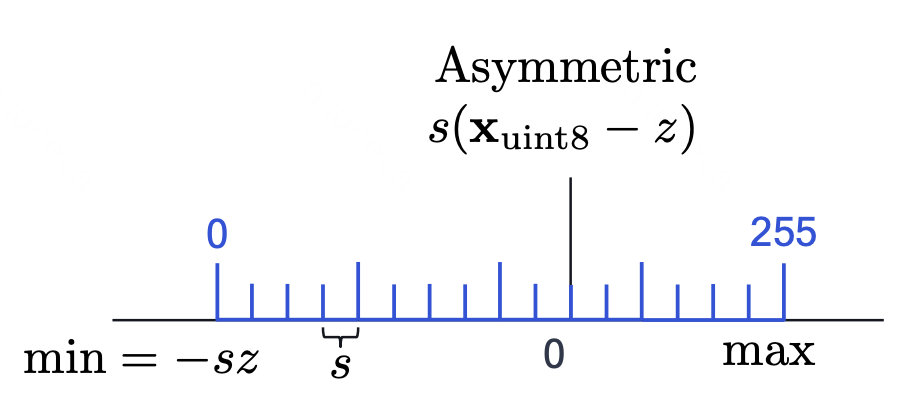

$$x_{int} = \text{clamp}\left(\lfloor \frac{x}{s} + z \rceil; 0, 2^b-1 \right)$$

$$\hat{x} = s \cdot (x_{int} - z)$$

where $z$ is the zero-point, which is used to ensure that the real zero after dequantization is equal to zero (i.e., quantized without error).

## Practice

In [ ]:
import numpy as np

In [ ]:
class SymmetricQuantizer:
    def __init__(self, num_bits):
        self.num_bits = num_bits
        self.scale = None

        self.q_min = -(2 ** (num_bits - 1))
        self.q_max = 2 ** (num_bits - 1) - 1

    def quantize(self, weights):
        max_val = np.max(np.abs(weights))
        self.scale = max_val / self.q_max
        normalized_weights = weights / self.scale
        quantized_weights = np.round(normalized_weights)
        quantized_weights = np.clip(quantized_weights, self.q_min, self.q_max)

        return quantized_weights

    def dequantize(self, quantized_weights):
        if self.scale is None:
            raise ValueError("Scale is not initialized. Call quantize() first.")

        return quantized_weights * self.scale

In [ ]:
M, N = 4, 3  # to display only part of the weights matrix
D_IN, D_OUT = 10, 8  # input and output dimentions
BATCH_SIZE = 32

In [ ]:
np.random.seed(21)
weights = np.random.randn(D_IN, D_OUT).astype(np.float32) * 0.1
print(f"Original weights:\n {weights[:M, :N]}")

In [ ]:
quantizer = SymmetricQuantizer(num_bits=8)
quantized_weights = quantizer.quantize(weights)
print(f"Quantized weights:\n {quantized_weights[:M, :N]}")

In [ ]:
dequantized_weights = quantizer.dequantize(quantized_weights)
print(f"Dequantized weights:\n {dequantized_weights[:M, :N]}")

# Activation-aware Weight Quantization (AWQ)


## Theory

https://arxiv.org/pdf/2306.00978

**Activations** are the outputs of neurons in a neural network after applying an activation function.

### Key Idea

AWQ leverages the observation that not all weights are equally important. By analyzing the **activation distribution**, AWQ identifies **salient weights** (those processing more important features) and applies scaling to protect them during quantization

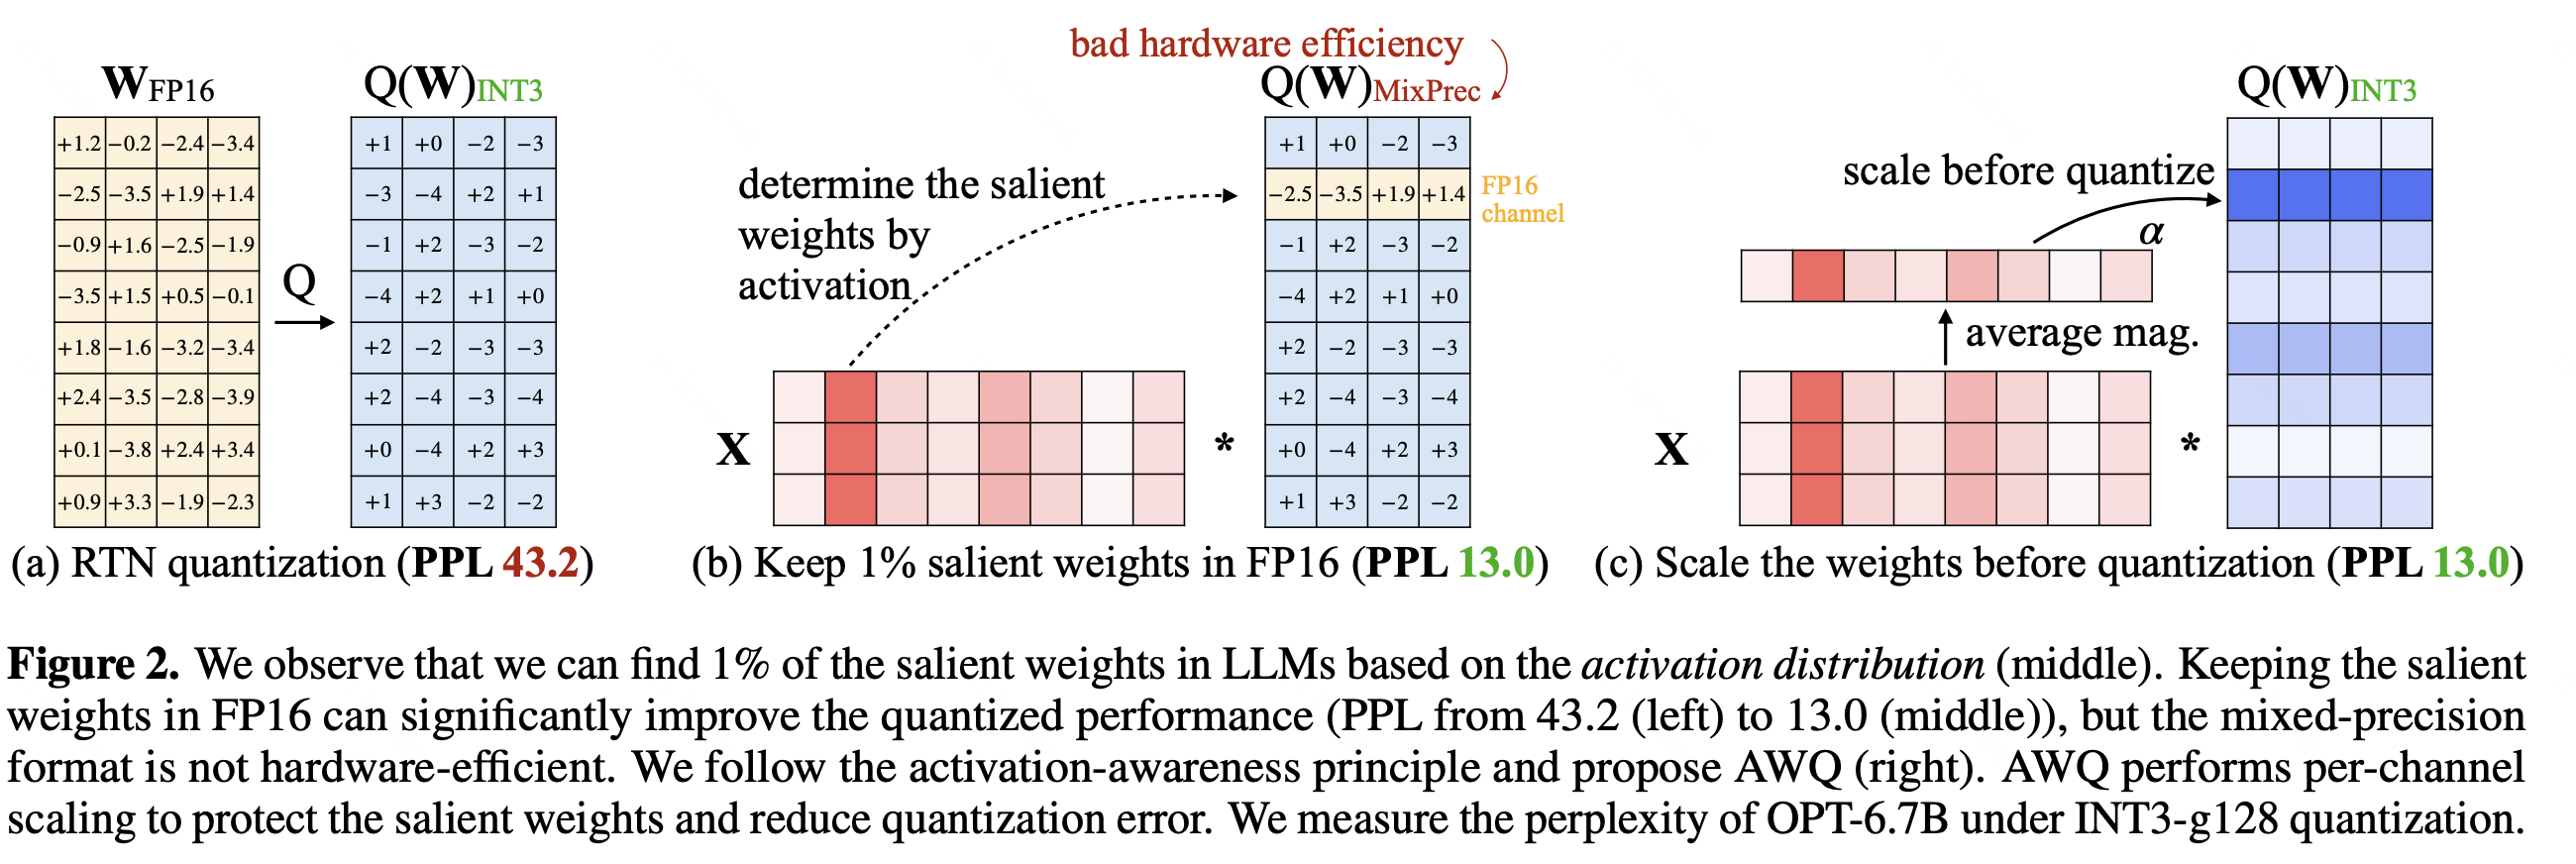

## Practice

Let's implement a toy example of AWQ

In [ ]:
class AWQSymmetricQuantizer:
    def __init__(self, num_bits):
        self.num_bits = num_bits
        self.scale = None

        self.q_min = -(2 ** (num_bits - 1))
        self.q_max = 2 ** (num_bits - 1) - 1

    def quantize(self, weights, activations):
        avg_activation = np.mean(np.abs(activations), axis=0)
        scaled_weights = weights * avg_activation[:, np.newaxis]

        max_val = np.max(np.abs(scaled_weights))
        self.scale = max_val / self.q_max
        normalized_weights = scaled_weights / self.scale
        quantized_weights = np.round(normalized_weights)
        quantized_weights = np.clip(quantized_weights, self.q_min, self.q_max)

        return quantized_weights

In [ ]:
np.random.seed(21)
activations = np.random.randn(BATCH_SIZE, D_IN).astype(np.float32) * 0.1

awq_quantizer = AWQSymmetricQuantizer(num_bits=8)
awq_quantized_weights = awq_quantizer.quantize(weights, activations)
print(f"Quantized weights:\n {awq_quantized_weights[:M, :N]}")

## Evaluating AWQ

This part is not ready yet :oops:

### Metrics

- **Perplexity**: Measures the quality of the quantized model on language modeling tasks
- **Speedup**: Compare inference time of quantized vs. full-precision models
- **Memory Reduction**: Measure the reduction in model size

### Experiment

We will compare the performance of a pre-trained LLM before and after applying AWQ

In [ ]:
!pip install autoawq

In [ ]:
import torch
from awq import AutoAWQForCausalLM
from transformers import AutoModelForCausalLM, AutoTokenizer

In [ ]:
MODEL_PATH = "facebook/opt-125m"
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [ ]:
INPUT_TEXT = "The quick brown fox jumps over the lazy dog."
inputs = tokenizer(INPUT_TEXT, return_tensors="pt")

with torch.no_grad():
    outputs = model.generate(inputs.input_ids, max_length=50)

print("Generated Text:", tokenizer.decode(outputs[0], skip_special_tokens=True))

In [ ]:
QUANT_CONFIG = {"zero_point": True, "q_group_size": 128, "w_bit": 4, "version": "GEMM"}
quantized_model = AutoAWQForCausalLM.from_pretrained(MODEL_PATH).cuda()
quantized_model.quantize(tokenizer, quant_config=QUANT_CONFIG, calib_data="OpenAssistant/oasst2", split="train")

## Conclusion

AWQ is a powerful technique for compressing and accelerating large language models. By focusing on salient weights and leveraging activation distributions, AWQ achieves significant reductions in model size and inference time without compromising performance. This makes it ideal for deploying LLMs on edge devices.